In [ ]:
# @title Libraries import
import os
import ee
import json
import glob
import random
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import statsmodels.api as sm
from IPython.display import clear_output
import gc
gc.collect()
# from google.colab import drive
# drive.mount('/content/drive')

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import balanced_accuracy_score
from sklearn.inspection import partial_dependence
from sklearn.metrics import roc_auc_score

from glob import glob
from IPython.core.pylabtools import figsize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib import rcParams
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error,r2_score, root_mean_squared_error
from sklearn.metrics import accuracy_score,log_loss, brier_score_loss, roc_auc_score

In [ ]:
#@title  Translated Gradient Boosted Trees Classifier for GEE
# var classifier = ee.Classifier.smileGradientTreeBoost({
#   numberOfTrees: 40,    // Maps from n_estimators = 40
#   shrinkage: 0.6,       // Maps from learning_rate = 0.6
#   samplingRate: 1.0,    // Maps from sklearn's default subsample = 1.0
#   maxNodes: 64,         // Maps from max_depth = 6 (calculated as 2^6)
#   seed: 42              // Maps from random_state = 42
# });

In [ ]:
# @title Setup
cv = 2
n_jobs = 2
n_estimators= 40
random_state = 42 # random.randint(0, 100)
scoring = 'balanced_accuracy'  #'F1', 'accuracy

# rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, n_jobs=n_jobs)
rf = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=6, learning_rate=0.6, random_state=random_state)

In [ ]:
# @title import data

target = 'Spreading'  # 'Extinguishing' 'Spreading'

# master_df = pd.read_csv('Bolivia_2019_Spreading.csv')
# stock_files = sorted(glob('/content/drive/MyDrive/fire/*.csv'))

stock_files = sorted(glob('/content/drive/MyDrive/fire/fire/Bolivia_2019_'+target+'.csv'))

master_df = pd.concat((pd.read_csv(file)#.assign(filename = file)
for file in stock_files), ignore_index=True)

print(master_df.shape)
print(master_df.columns)

(114438, 103)
Index(['system:index', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07',
       'A08',
       ...
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground', 'slope',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'upa', 'upg', 'ΣMW', 'ΣMW_1', '.geo'],
      dtype='object', length=103)


Missing values per column:
Fire_Duration_h      70696
hours_elapsed_max    70696
hours_elapsed_min    70696
slope                14556
dtype: int64


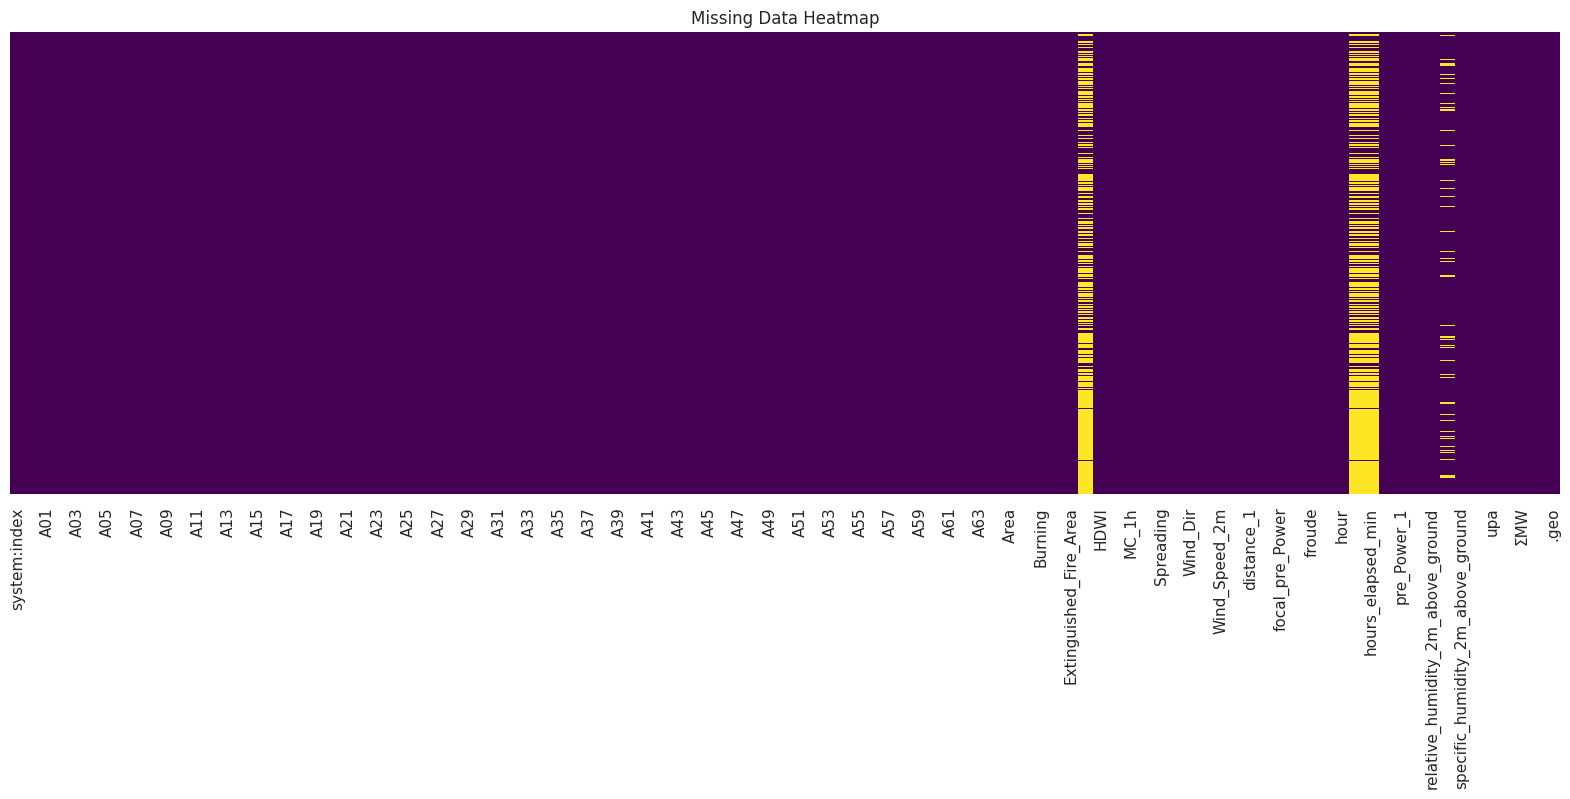

In [ ]:
# @title Check for missing values in master_df
print("Missing values per column:")
print(master_df.isnull().sum()[master_df.isnull().sum() > 0])

plt.figure(figsize=(20, 6))
sns.heatmap(master_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [ ]:
# @title cleanup data
# df = pd.read_csv('rh_98_2324.csv')
# df = pd.read_csv('/content/drive/MyDrive/fire/sample0.csv')
# df = pd.concat([df1, df2])
print(master_df.shape)
# df.info()
# print(df.head())
master_df = master_df.drop_duplicates()
print(master_df.shape)
# master_df = master_df.dropna()
# print(master_df.shape)
# print(master_df.columns)
# master_df.to_csv('master_df.csv', index=False)

(114438, 103)
(114438, 103)


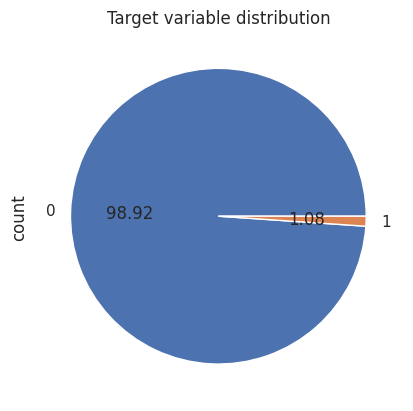

In [ ]:
ax = master_df['Spreading'].value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title("Target variable distribution")

In [ ]:
ax = master_df['Extinguishing'].value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title("Target variable distribution")

You can use super under sample for the spreading dataset but use the simple procedure for the extinguishing dataset

In [ ]:
# @title Simple Under-Sample

df = master_df

y = df[target]
X = df

rus = RandomUnderSampler(sampling_strategy = 'not minority', random_state=random_state)
new_df, y = rus.fit_resample(df, y)

print(new_df.shape)

In [ ]:
# @title Super Under-Sample

negative_df = master_df.loc[master_df[target] == 0]

y = negative_df.hour
X = negative_df

rus = RandomUnderSampler(sampling_strategy = 'not minority', random_state=random_state)
negative_df, y = rus.fit_resample(negative_df, y)


positive_df = master_df.loc[master_df[target] == 1]

new_df = pd.concat([negative_df, positive_df])

y = new_df[target]
X = new_df

new_df, y = rus.fit_resample(X, y)
print(new_df.shape)

(2476, 103)


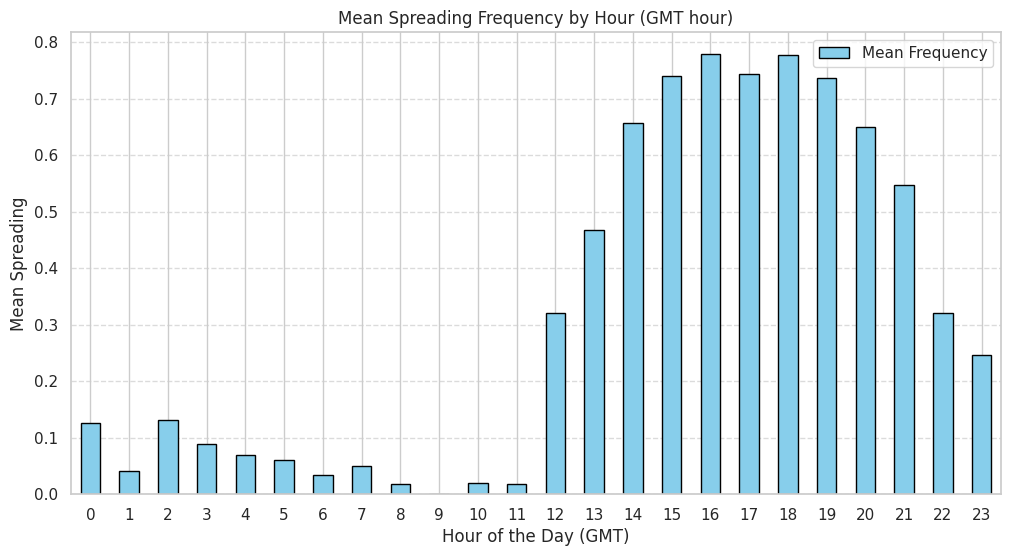

In [ ]:
# @title pivot data & plot as columns

pivot_table = new_df.pivot_table(index='hour', values=[target], aggfunc='mean')

# Plotting as columns
plt.figure(figsize=(12, 6))
pivot_table.plot(kind='bar', ax=plt.gca(), color='skyblue', edgecolor='black')
plt.title(f'Mean {target} Frequency by Hour (GMT hour, Bolivia is GTM-4)')
plt.xlabel('Hour of the Day (GMT)')
plt.ylabel(f'Mean {target}')
plt.xticks(rotation=0)
plt.legend(['Mean Frequency'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# pivot_table

In [ ]:
# @title define X and Y

df = new_df

y = df[target]

# Extinguishing
# selected_features = ['A11', 'A21', 'A60', 'focal_pre_Power', 'hnd', 'pre_Power', 'pre_Power_1', 'upg', 'ΣMW']#2019
# selected_features = ['A60', 'A11', 'A21', 'hnd', 'precipitable_water_entire_atmosphere', 'upa']#2019

# Spreading
# selected_features = ['distance_1', 'focal_pre_Power', 'focal_ΣMW', 'A21', 'A42', 'A62', 'upa', 'HDWI', 'MC_1h']#2019
selected_features =  ['A11', 'A21', 'A42', 'A49', 'A62', 'HDWI', 'MC_1h', 'hnd', 'upg']#2019

X = df[selected_features]

# X = df.drop(columns=['Extinguished_Fire_Area', 'Active_Fire_Area', 'Burning','Power','hours_elapsed_max','hours_elapsed_min','hour','Wind_Dir','.geo','system:index','Fire_Duration_h', 'froude', 'slope', 'Burned', 'LC_Type4','Depth','Area',
# #  'pre_Power', 'pre_Power_1', 'distance_1', 'focal_pre_Power', 'focal_ΣMW', 'ΣMW_1','ΣMW','distance',
# 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground','HDWI', 'MC_1h', 'VPD_air','Wind_Speed_10m', 'Wind_Speed_2m',
# #  'elv','hnd','upa', 'upg','slope','precipitable_water_entire_atmosphere',
# target])
# # print(X.shape)

In [ ]:
# @title VIF based Feature Selection
# Rank X features based on variance inflation factor from lower to higher and assign a corresponding score (1, 2, 3, etc.). Assign score_1.
# Rank X features based on features’ importance to classify y on the 50% test set from higher to lower and assign a corresponding score (1, 2, 3, etc.). Assign score_2.
# Add score_1 and score_2 to assign score_3 and eliminate the feature with the highest score_3, that is the feature with the higher VIF and lower importance combined.
# Iterate until there are no features with a variance inflation factor greater than a user defined value.

weight_1 = 1.2
weight_2 = 0.8
VIF_threshold = 3

def calculate_vif(X):
    vif = pd.DataFrame()
    vif['features'] = X.columns
    vif['VIF_Values'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

def feature_selection(X, y, threshold= VIF_threshold, random_state=random_state):
    #Initial features
    features = list(X.columns)

    while True:
      #Calculate VIF
      vif_df = calculate_vif(X[features])
      vif_df = vif_df.sort_values('VIF_Values')
      vif_df['score_1'] = range(1, len(vif_df)+1)

      #Train a model and calculate importance
      X_train, X_test, y_train, y_test = train_test_split(X[features], y.values.ravel(), test_size=0.5, random_state=random_state)
      OOSmodel = rf.fit(X_train, y_train)
      importance = OOSmodel.feature_importances_

      # Update the features list based on the columns in X_train after splitting
      current_features = list(X_train.columns)
      imp_df = pd.DataFrame({'feature': current_features, 'importance': importance})
      imp_df = imp_df.sort_values('importance', ascending=False)
      imp_df['score_2'] = range(1, len(imp_df) + 1)

      #Combine scores
      combined_df = pd.merge(vif_df, imp_df, left_on='features', right_on='feature')
      combined_df['score_3'] = combined_df['score_1'] * weight_1 + combined_df['score_2'] * weight_2

      #Find feature to remove
      feature_to_remove = combined_df.sort_values('score_3', ascending=False).iloc[0]['features']

      #Check if VIF is above threshold
      max_vif = vif_df['VIF_Values'].max()
      if max_vif <= threshold:
          break

      #Remove feature
      features.remove(feature_to_remove)

    return features

selected_features = feature_selection(X, y)
print(selected_features)
X_selected = df[selected_features]

['A11', 'A21', 'A42', 'A49', 'A62', 'HDWI', 'MC_1h', 'hnd', 'upg']


In [ ]:
# @title VIF calc X_selected

def calculate_vif(X_selected):
  vif = pd.DataFrame()
  vif['features'] = X_selected.columns
  vif['VIF_Values'] = [variance_inflation_factor(X_selected.values, i) for i in range (X_selected.shape[1])]
  vif = vif.sort_values('VIF_Values')
  return(vif)
features = X_selected
# print(features.head())
calculate_vif(features)

,features,VIF_Values
8,upg,1.016852
5,HDWI,1.610526
4,A62,1.613204
1,A21,1.650164
6,MC_1h,2.027157
2,A42,2.147522
3,A49,2.183239
7,hnd,2.326026
0,A11,2.395708


In [ ]:
# @title OOS X_selected features importance

X_train, X_test, y_train, y_test = train_test_split (X_selected, y, test_size=0.5,random_state=random_state)

OOSmodel = rf.fit(X_train, y_train)

importance = OOSmodel.feature_importances_
columns = X_selected.columns
imp = pd.Series(importance,columns).sort_values(ascending=False).to_string()
print(imp)

HDWI     0.420868
MC_1h    0.170408
A11      0.082659
A62      0.065652
hnd      0.064315
A42      0.057664
A49      0.052211
A21      0.044582
upg      0.041640


Balanced Accuracy 0.81
Sensitivity (Recall) 0.83
Specificity 0.78


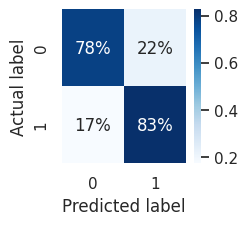

In [ ]:
# @title confusion matrix

y_pred = OOSmodel.predict(X_test)

bal_acc = balanced_accuracy_score(y_test, y_pred)

#  Model evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Balanced Accuracy {bal_acc:.2f}")
print(f"Sensitivity (Recall) {sensitivity:.2f}")
print(f"Specificity {specificity:.2f}")

cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix to percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(2, 2))
sns.heatmap(cm_normalized, annot=True, fmt=".0%", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# plt.title('Confusion Matrix (Validation Set)')
plt.show()

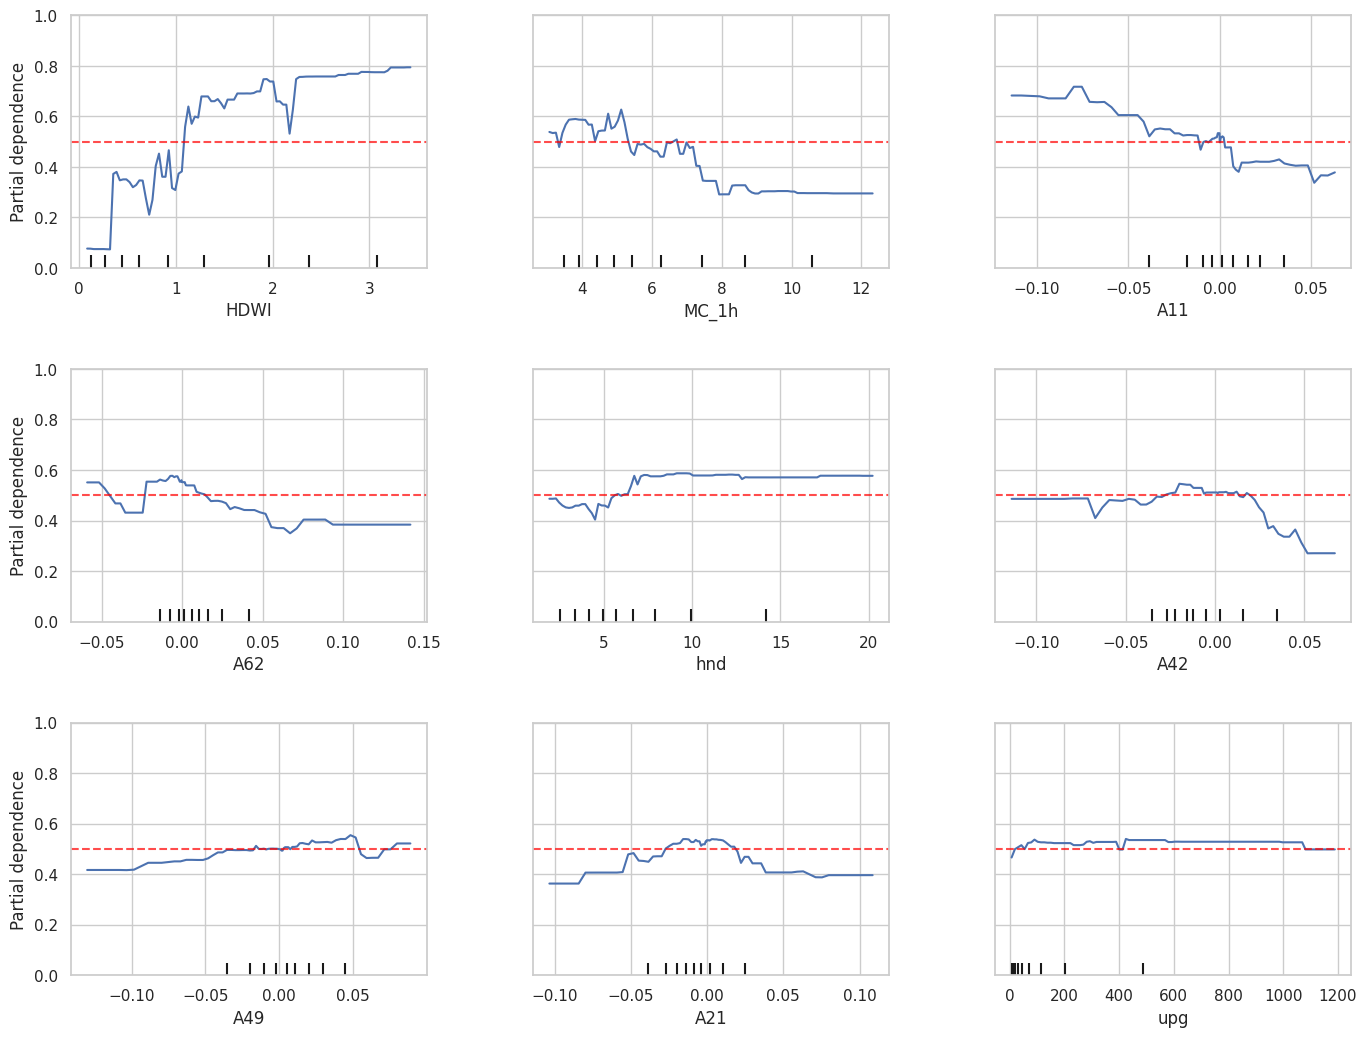

In [ ]:
#@title Partial Dependence Plots on test data (Probability Scale)

# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid")

current_importances = pd.Series(OOSmodel.feature_importances_, index=X_test.columns)
features_to_plot = current_importances.sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(16, 12))
display = PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features=features_to_plot,
    kind="average",
    method="brute",
    response_method='predict_proba',
    ax=ax,
    n_cols=3
)

for axis in display.axes_.flatten():
    if axis is not None:
        axis.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axis.set_ylim(0, 1) # Aseguramos que el eje Y muestre el rango 0-1

# plt.suptitle('Partial Dependence Plots (Probability Scale - 50% Threshold in Red)', fontsize=16)

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.3)
plt.show()

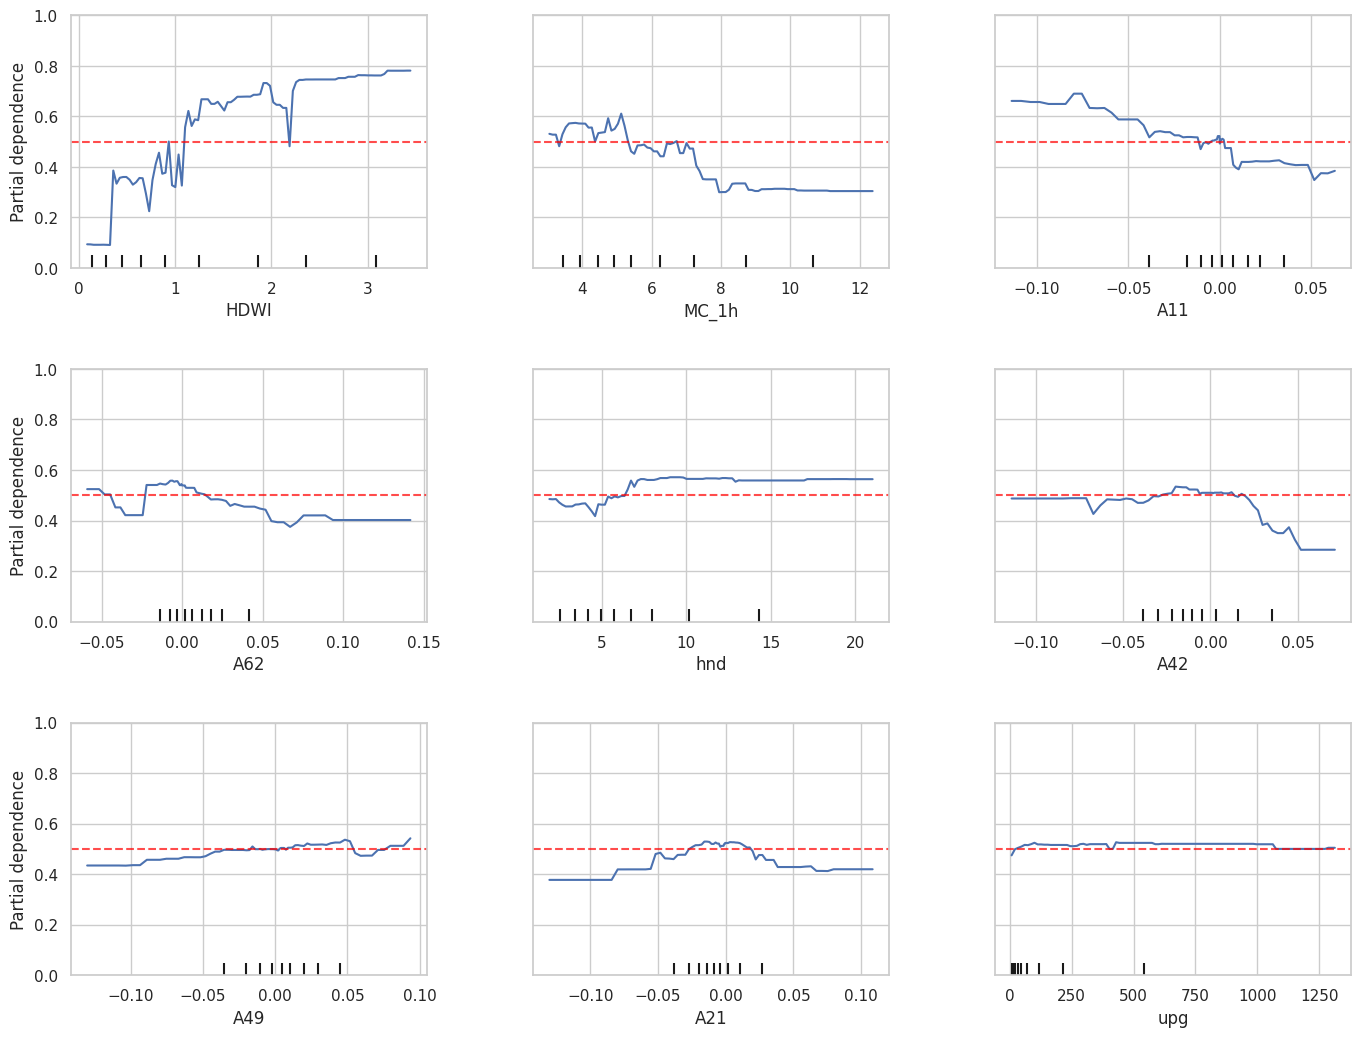

In [ ]:
# @title Partial Dependence Plots on the entire set (Probability Scale)

fig, ax = plt.subplots(figsize=(16, 12))

display = PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features=features_to_plot,
    kind="average",
    method="brute",
    response_method='predict_proba',
    ax=ax,
    n_cols=3
)

for axis in display.axes_.flatten():
    if axis is not None:
        axis.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axis.set_ylim(0, 1)

# plt.suptitle('Partial Dependence Plots (Probability Scale - 50% Threshold in Red)', fontsize=16)
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.3)
plt.show()

In [ ]:
# @title Training the model to make predictions
PREDICT_model = rf.fit(X, y)

In [ ]:
# @title # Import validation set

stock_files = sorted(glob('/content/drive/MyDrive/fire/fire/Bolivia_2021_'+target+'.csv'))

master_df = pd.concat((pd.read_csv(file)#.assign(filename = file)
for file in stock_files), ignore_index=True)

In [ ]:
# @title Simple Under-Sample

df = master_df

y = df[target]
X = df[selected_features]

rus = RandomUnderSampler(sampling_strategy = 'not minority', random_state=random_state)
new_df, y = rus.fit_resample(df, y)

print(new_df.shape)

In [ ]:
# @title Super Under-Sample

negative_df = master_df.loc[master_df[target] == 0]

y = negative_df.hour
X = negative_df

rus = RandomUnderSampler(sampling_strategy = 'not minority', random_state=random_state)
negative_df, y = rus.fit_resample(negative_df, y)


positive_df = master_df.loc[master_df[target] == 1]

new_df = pd.concat([negative_df, positive_df])

y = new_df[target]
X = new_df

new_df, y = rus.fit_resample(X, y)
print(new_df.shape)

(1024, 103)


In [ ]:
# @title define X and Y

X = new_df[selected_features]
y_validation = new_df[[target]]

print(f"Validation features shape: {X.shape}")
print(f"Validation target shape: {y_validation.shape}")

Validation features shape: (1024, 9)
Validation target shape: (1024, 1)


Balanced Accuracy 0.72
Sensitivity (Recall) 0.76
Specificity 0.68


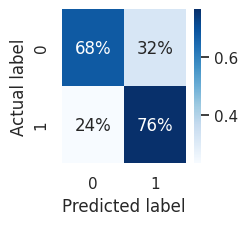

In [ ]:
# @title Prediction ad Evaluation


y_pred = PREDICT_model.predict(X)

bal_acc = balanced_accuracy_score(y_validation, y_pred)

#  Model evaluation
tn, fp, fn, tp = confusion_matrix(y_validation, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Balanced Accuracy {bal_acc:.2f}")
print(f"Sensitivity (Recall) {sensitivity:.2f}")
print(f"Specificity {specificity:.2f}")

cm = confusion_matrix(y_validation, y_pred)

# Normalize the confusion matrix to percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(2, 2))
sns.heatmap(cm_normalized, annot=True, fmt=".0%", cmap="Blues", xticklabels=np.unique(y_validation), yticklabels=np.unique(y_validation))
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [ ]:
# @title Flush Cache and Collect Garbage
import gc

# Trigger garbage collection
gc.collect()

print("Cache flushed and garbage collection complete.")

Cache flushed and garbage collection complete.


In [ ]:
# @title Export training data (if you whish)

# df_final = pd.concat([y, X_selected], axis=1)
# pd.DataFrame(df_final).to_csv('Training_Data.csv', index=False)